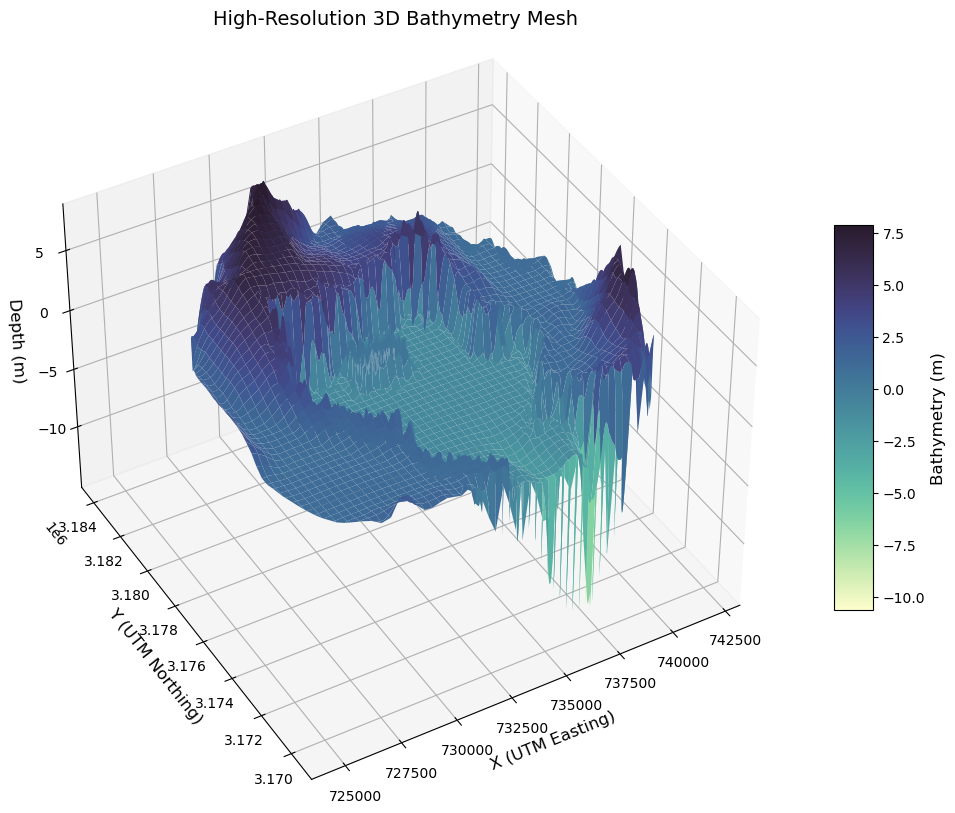

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
import mikeio
from mpl_toolkits.mplot3d import Axes3D
import cmocean

# Load the full mesh file
mesh_file = r"D:\Phd Research\Wave Model\small scale port lavaca\Mesh file\updated_bathymetry.mesh"
mesh = mikeio.Mesh(mesh_file)

# Extract node coordinates (X, Y) and bathymetry (Z)
X, Y, Z = mesh.node_coordinates[:, 0], mesh.node_coordinates[:, 1], mesh.zn

# Create a high-resolution regular grid
num_points = 800  # Increase for better resolution
grid_x, grid_y = np.linspace(X.min(), X.max(), num_points), np.linspace(Y.min(), Y.max(), num_points)
grid_x, grid_y = np.meshgrid(grid_x, grid_y)

# Interpolate bathymetry onto the grid
grid_z = griddata((X, Y), Z, (grid_x, grid_y), method='cubic')

# Create figure
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot surface with a beautiful colormap
surf = ax.plot_surface(grid_x, grid_y, grid_z, cmap=cmocean.cm.deep, edgecolor='none', linewidth=0, antialiased=True)


# Add color bar
cbar = fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)
cbar.set_label('Bathymetry (m)', fontsize=12)

# Adjust viewing angle
ax.view_init(elev=40, azim=240)  # Adjust angle for better visualization

# Labels and title
ax.set_xlabel('X (UTM Easting)', fontsize=12)
ax.set_ylabel('Y (UTM Northing)', fontsize=12)
ax.set_zlabel('Depth (m)', fontsize=12)
ax.set_title('High-Resolution 3D Bathymetry Mesh', fontsize=14)

# Show plot
plt.show()
